## Child Malnutrition
Analyzing child malnutrition and mortality trends across Sub-Saharan Africa using WHO data

In [1]:
import pandas as pd 
import requests 
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connecting to WHO API to get data
url = "https://ghoapi.azureedge.net/api" 
response = requests.get(f"{url}/Indicator")
print("Connection status: ", response.status_code ) 

Connection status:  200


In [3]:
# Checking to see all indicators available

indicator_list = response.json()['value']
df = pd.DataFrame(indicator_list)
 
print(len(df))

df[['IndicatorCode', 'IndicatorName']].head(10)

3070


,IndicatorCode,IndicatorName
0,EMFLIMITPOWERDENSITY900,Power density limit at 900 MHz (W/m^2)
1,EMFPOWERFREQUENCY,Power frequency (Hz)
2,FINPROTECTION_CATA_ESTIMATE_AVAILABLE,Availability of estimates on large health exp...
3,HIV_0000000001,Estimated number of people (all ages) living w...
4,FINPROTECTION_CATA_TOT_25_LEVEL_SH,Population with household spending on health g...
5,FINPROTECTION_IMP_NP_190_LEVEL_SH,Total population pushed below the $1.90 a day...
6,HIV_0000000026,Number of new HIV infections
7,HRH_06,Number of community health workers
8,HRH_07,Number of traditional birth attendants
9,HIV_0000000009,Reported number of people receiving antiretrov...


In [4]:
# Search for nutrition indicators we might be interested in. 

keywords = 'child|children|stunting|wasting|underweight|overweight|breastfeed|anaemia|malnutrition|mortality'
 
interests = df[
    df['IndicatorName'].str.lower().str.contains(keywords, na=False)
][['IndicatorCode', 'IndicatorName']]
 
print("Related indicators found: ", len(interests))

interests  
 

Related indicators found:  211


,IndicatorCode,IndicatorName
17,EQ_OVERWEIGHTADULT,Prevalence of overweight and obesity
34,HIV_0000000011,Reported number of children receiving antiretr...
35,HIV_0000000012,Reported number of children receiving antiretr...
37,HIV_0000000021,Estimated number of pregnant women living with...
38,HIV_0000000023,Estimated number of children needing antiretro...
...,...,...
3027,CHILDDEATH5TO14,Number of deaths among children 5 to 14 years ...
3031,NCD_CCS_OvwtPlan,Existence of operational policy/strategy/actio...
3040,NTD_LEPR13,New leprosy child case detection rate (less th...
3060,NUTRITION_ANAEMIA_PREGNANT_PREV,Prevalence of anaemia in pregnant women (aged ...


In [ ]:
# These are the 10 malnutrition indicators we are interested in, with their corresponding column names for the final dataset.
indicators = { 
    "NUTRITION_ANT_HAZ_NE2":  "stunting_pct",                  
    "NUTRITION_ANT_WHZ_NE2":  "wasting_pct",                     
    "NUTRITION_ANT_WAZ_NE2":  "underweight_pct",                
    "NUTRITION_ANT_WHZ_PE2":  "overweight_pct",                  
    "NUTRITION_ANT_WHZ_NE3":  "severe_wasting_pct",              
    "NUTRITION_2005":          "min_acceptable_diet_pct",        
    "WHOSIS_000001":           "under_five_mortality_rate",      
    "WHOSIS_000002":           "infant_mortality_rate",          
    "WHOSIS_000003":           "neonatal_mortality_rate",       
    "NUTRITION_570":           "early_initiation_breastfeeding", 
}

# Below are the Sub-Saharan Africa countries and their country_code
ssa_countries = {
    "AGO","BEN","BWA","BFA","BDI","CPV","CMR","CAF","TCD","COM",
    "COD","COG","errorbarV","DJI","GNQ","ERI","SWZ","ETH","GAB","GMB",
    "GHA","GIN","GNB","KEN","LSO","LBR","MDG","MWI","MLI","MRT",
    "MUS","MOZ","NAM","NER","NGA","RWA","STP","SEN","SLE","SOM",
    "ZAF","SSD","SDN","TZA","TGO","UGA","ZMB","ZWE"
}
 
print("Indicators to download :", len(indicators))
print("SSA countries included :",len(ssa_countries))
 

Indicators to download : 10
SSA countries included : 48


In [6]:
# Function to fetch data for a given indicator code and return a DataFrame with the relevant columns.

def get_indicator(code, column_name):
 
    url1 = f"{url}/{code}"
    print(column_name, end=" ", flush=True)
 
    response = requests.get(url1, timeout=30)

    # Checking the response is valid before parsing
    if response.status_code != 200 or not response.text.strip():
        print(response.status_code)
        return pd.DataFrame()
    indi_records = response.json().get("value", [])
 
    # Keeping only SSA country rows that has a numeric value
    rows = []
    for r in indi_records:
        country_code = r.get("SpatialDim", "")
        value        = r.get("NumericValue")
        if country_code in ssa_countries and value is not None and 2010 <= r.get("TimeDim", 0) <= 2026:
            rows.append({
                "country_code":      country_code,
                "year":      r.get("TimeDim"),
                column_name: value,
            })
 
    df = pd.DataFrame(rows)
    print(len(df), "rows")
    return df
 


In [ ]:
# Function to download all the data per indicators and merge them 

def data_load():
 
    data = []
    for code, name in indicators.items():
        df = get_indicator(code, name)
        if not df.empty:
            data.append(df)
 
    if not data:
        print("\nNo data retrieved.")
        return pd.DataFrame()
 
    # Merge all indicators on country_code + year
    merged = data[0]
    for df in data[1:]:
        col = [c for c in df.columns if c not in ("country_code", "year")]
        merged = merged.merge(df[["country_code", "year"] + col],
                              on=["country_code", "year"], how="outer")
 
    merged = merged.sort_values(["country_code", "year"]).reset_index(drop=True)
 
    print("\n  Rows     :", len(merged))
    print("  Countries: ", merged['country_code'].nunique())
    print("  Years    : ", int(merged['year'].min()), ",", int(merged['year'].max()))
    print("  Columns  : ", list(merged.columns))
    return merged
 
 

In [8]:
df = data_load()
df.head(10)

stunting_pct 16899 rows
wasting_pct 15915 rows
underweight_pct 404
overweight_pct 404
severe_wasting_pct 404
min_acceptable_diet_pct 51 rows
under_five_mortality_rate 1728 rows
infant_mortality_rate 1728 rows
neonatal_mortality_rate 672 rows
early_initiation_breastfeeding 77 rows

  Rows     : 11738663
  Countries:  48
  Years    :  2010 , 2024
  Columns  :  ['country_code', 'year', 'stunting_pct', 'wasting_pct', 'min_acceptable_diet_pct', 'under_five_mortality_rate', 'infant_mortality_rate', 'neonatal_mortality_rate', 'early_initiation_breastfeeding']


,country_code,year,stunting_pct,wasting_pct,min_acceptable_diet_pct,under_five_mortality_rate,infant_mortality_rate,neonatal_mortality_rate,early_initiation_breastfeeding
0,AGO,2010,NaN,NaN,NaN,57.964611,49.261258,36.197696,NaN
1,AGO,2010,NaN,NaN,NaN,57.964611,51.486706,36.197696,NaN
2,AGO,2010,NaN,NaN,NaN,57.964611,50.368592,36.197696,NaN
3,AGO,2010,NaN,NaN,NaN,60.071615,49.261258,36.197696,NaN
4,AGO,2010,NaN,NaN,NaN,60.071615,51.486706,36.197696,NaN
5,AGO,2010,NaN,NaN,NaN,60.071615,50.368592,36.197696,NaN
6,AGO,2010,NaN,NaN,NaN,55.861059,49.261258,36.197696,NaN
7,AGO,2010,NaN,NaN,NaN,55.861059,51.486706,36.197696,NaN
8,AGO,2010,NaN,NaN,NaN,55.861059,50.368592,36.197696,NaN
9,AGO,2011,NaN,NaN,NaN,60.907942,51.054464,34.983319,NaN


In [12]:
# Checking for duplicates per country per year since the rows loads are over 11,000,000 

duplicate = df.groupby(['country_code', 'year']).size().reset_index(name='count')
print("Unique country-year combos: ", len(duplicate)) 
print("Rows with duplicates (>1 per country-year):", (duplicate['count'] > 1).sum())
print("\nMax duplicates for a single country per year:", duplicate['count'].max())
print("Average rows per country-year:", f"{duplicate['count'].mean():.2f}")


Unique country-year combos:  676
Rows with duplicates (>1 per country-year): 597

Max duplicates for a single country per year: 99225
Average rows per country-year: 17364.89


In [ ]:
# Showing an example of a country per year with duplicates, if any exist

if (duplicate['count'] > 1).any():
    example = duplicate[duplicate['count'] > 1].iloc[0]
    country, year = example['country_code'], example['year']
    print(f"\nExample: {country}, {year} - {example['count']} rows")
    display(df[(df['country_code'] == country) & (df['year'] == year)].head())



Example: AGO, 2010 - 9 rows


,country_code,year,stunting_pct,wasting_pct,min_acceptable_diet_pct,under_five_mortality_rate,infant_mortality_rate,neonatal_mortality_rate,early_initiation_breastfeeding
0,AGO,2010,NaN,NaN,NaN,57.964611,49.261258,36.197696,NaN
1,AGO,2010,NaN,NaN,NaN,57.964611,51.486706,36.197696,NaN
2,AGO,2010,NaN,NaN,NaN,57.964611,50.368592,36.197696,NaN
3,AGO,2010,NaN,NaN,NaN,60.071615,49.261258,36.197696,NaN
4,AGO,2010,NaN,NaN,NaN,60.071615,51.486706,36.197696,NaN


Same countries showing different mortality rates for the same year, like 57.96 versus 60.07 for under-five mortality, and infant mortality bounerrorbarng between 51.49, 50.37, and 49.26.

These are probably different estimates or subgroups, things like male versus female, urban versus rural, or different age brackets within the indicator.

Since the goal here is trend analysis, correlations and more, we are going to take the mean, just a simple average across whatever estimates are available for that country-year.

In [ ]:
# Aggregate by taking the mean for each country peryear

df_clean = df.groupby(['country_code', 'year'], as_index=False).mean()

print(f"Original rows: {len(df)}")
print(f"After aggregation: {len(df_clean)}")
print(f"Countries: {df_clean['country_code'].nunique()}")
print(f"Year range: {df_clean['year'].min()} – {df_clean['year'].max()}")


Original rows: 11738663
After aggregation: 676
Countries: 48
Year range: 2010 – 2024


In [13]:
# Checking the result of AGO to confirm as that was the earlier example we looked at
print("\nExample AGO 2010 after aggregation:")
display(df_clean[(df_clean['country_code'] == 'AGO') & (df_clean['year'] == 2010)])


Example AGO 2010 after aggregation:


,country_code,year,stunting_pct,wasting_pct,min_acceptable_diet_pct,under_five_mortality_rate,infant_mortality_rate,neonatal_mortality_rate,early_initiation_breastfeeding
0,AGO,2010,NaN,NaN,NaN,57.965762,50.372185,36.197696,NaN


In [14]:
# Checking the data coverage for each column to know the missing values and the percentage of coverage for each column in the cleaned dataset.
coverage = df_clean.isnull().sum()
total_rows = len(df_clean)
coverage_pct = (1 - coverage / total_rows) * 100

coverage_df = pd.DataFrame({
    'Missing': coverage,
    'Non-Missing': total_rows - coverage,
    'Coverage %': coverage_pct
}).sort_values('Coverage %', ascending=False)

print("Column coverage:\n")
display(coverage_df)

Column coverage:



,Missing,Non-Missing,Coverage %
country_code,0,676,100.000000
year,0,676,100.000000
neonatal_mortality_rate,4,672,99.408284
under_five_mortality_rate,100,576,85.207101
infant_mortality_rate,100,576,85.207101
stunting_pct,466,210,31.065089
wasting_pct,474,202,29.881657
early_initiation_breastfeeding,599,77,11.390533
min_acceptable_diet_pct,625,51,7.544379


In [15]:
# Dropping columns with low coverage 

columns_drop = ['min_acceptable_diet_pct', 'early_initiation_breastfeeding']
df_clean = df_clean.drop(columns=columns_drop)

In [16]:
print("Columns after dropping low-coverage ones:", list(df_clean.columns))
print("Shape:", df_clean.shape)

Columns after dropping low-coverage ones: ['country_code', 'year', 'stunting_pct', 'wasting_pct', 'under_five_mortality_rate', 'infant_mortality_rate', 'neonatal_mortality_rate']
Shape: (676, 7)


In [18]:
# Interpolating of missing values will be done by country to help fill in the black space for easy analysis 

df_interpolate = df_clean.copy()

# each column is going to be interpolated and  grouped by country
cols_interpolate = ['stunting_pct', 'wasting_pct', 'under_five_mortality_rate', 
                       'infant_mortality_rate', 'neonatal_mortality_rate']

for col in cols_interpolate:
    df_interpolate[col] = df_interpolate.groupby('country_code')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

#printing the missing values after interpolation to know if there are any remaining missing values after the interpolation process.
print(df_interpolate[cols_interpolate].isnull().sum())

stunting_pct                 42
wasting_pct                  42
under_five_mortality_rate     0
infant_mortality_rate         0
neonatal_mortality_rate       0
dtype: int64


In [19]:
print("\nValue ranges after interpolation:")
for col in cols_interpolate:
    print(f"{col}: {df_interpolate[col].min():.2f} to {df_interpolate[col].max():.2f}")


Value ranges after interpolation:
stunting_pct: 6.29 to 56.91
wasting_pct: 0.09 to 15.98
under_five_mortality_rate: 43.92 to 74.90
infant_mortality_rate: 39.24 to 65.31
neonatal_mortality_rate: 6.76 to 46.69


In [20]:
#finding the countries that still have missing values for stunting_pct after interpolation and printing the number of affected countries and their country codes.
missing_stunting = df_interpolate[df_interpolate['stunting_pct'].isnull()]
countries_with_issue = missing_stunting['country_code'].unique()

print("Countries affected:", {len(countries_with_issue)})
print("Which countries:", sorted(countries_with_issue))

Countries affected: {3}
Which countries: ['BWA', 'MUS', 'SOM']


In [21]:
# Dropping countries with missing data after interpolation.

drop_coun = ['BWA', 'MUS', 'SOM']
final_df = df_interpolate[~df_interpolate['country_code'].isin(drop_coun)].copy()

print("Countries remaining:", {final_df['country_code'].nunique()})

Countries remaining: {45}


In [22]:
print("Remaining NaNs:", final_df.isnull().sum().sum())

Remaining NaNs: 0


In [23]:
print("Final dataset shape:", final_df.shape)

Final dataset shape: (634, 7)


In [24]:
print("Summary statistics after cleaning:")
display(final_df.describe())

Summary statistics after cleaning:


,year,stunting_pct,wasting_pct,under_five_mortality_rate,infant_mortality_rate,neonatal_mortality_rate
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,2016.547319,30.217290,4.032010,62.050924,54.078351,27.199938
std,4.065242,9.978068,2.915229,4.806761,4.239318,7.060151
min,2010.000000,6.293333,0.088000,46.514865,40.863562,6.760314
25%,2013.000000,23.087368,1.809971,59.294863,51.732930,23.242689
50%,2017.000000,30.026090,3.228421,62.086292,54.018002,26.859549
75%,2020.000000,36.801491,5.651744,64.698396,56.322694,32.541297
max,2024.000000,56.913333,15.983333,74.902749,65.311503,44.712065


#### Trend visualization


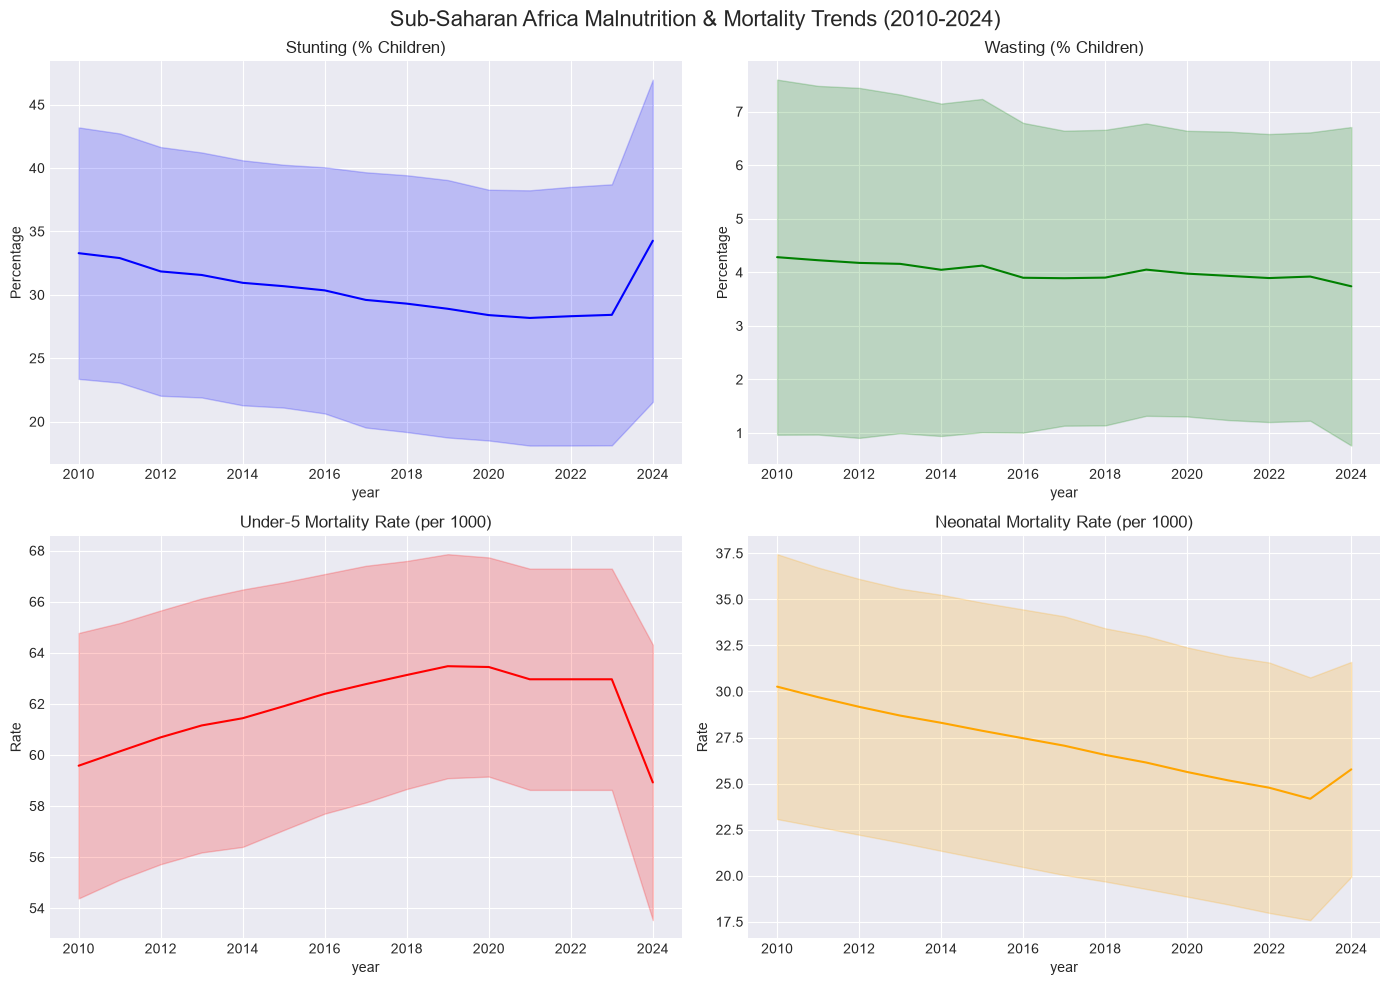

In [26]:
# Visualizing the trends of malnutrition and mortality indicators in Sub-Saharan Africa from 2010 to 2024.

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#  Regional average trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sub-Saharan Africa Malnutrition & Mortality Trends (2010-2024)', fontsize=16)

# Stunting trend
sns.lineplot(data=final_df, x='year', y='stunting_pct', 
             errorbar='sd', ax=axes[0,0], color='blue')
axes[0,0].set_title('Stunting (% Children)')
axes[0,0].set_ylabel('Percentage')

# Wasting trend
sns.lineplot(data=final_df, x='year', y='wasting_pct', 
             errorbar='sd', ax=axes[0,1], color='green')
axes[0,1].set_title('Wasting (% Children)')
axes[0,1].set_ylabel('Percentage')

# Under-five mortality
sns.lineplot(data=final_df, x='year', y='under_five_mortality_rate', 
             errorbar='sd', ax=axes[1,0], color='red')
axes[1,0].set_title('Under-5 Mortality Rate (per 1000)')
axes[1,0].set_ylabel('Rate')

# Neonatal mortality
sns.lineplot(data=final_df, x='year', y='neonatal_mortality_rate', 
             errorbar='sd', ax=axes[1,1], color='orange')
axes[1,1].set_title('Neonatal Mortality Rate (per 1000)')
axes[1,1].set_ylabel('Rate')

plt.tight_layout()
plt.show()

While progress was made in reducing child malnutrition and mortality in Sub-Saharan Africa during the 2010s, recent years show an alarming reversal, particularly in stunting and under-5 mortality. This suggests that gains made over the past decade may be fragile and vulnerable to external shocks. However, there are no current data from 2025 to conclude

In [ ]:
# Find countries with largest stunting increase 
stunt = final_df.groupby('country_code').agg({
    'stunting_pct': lambda x: x.iloc[-1] - x.iloc[0]  
}).sort_values('stunting_pct', ascending=False)

print("Countries with largest stunting increase:")
display(stunt.head(10))

# Top 5 countries with stunting decline
print("\nCountries with largest stunting decline:")
display(stunt.tail(5))

Countries with largest stunting increase:


,stunting_pct
country_code,
SDN,4.308231
LSO,1.967021
NER,1.429333
CPV,0.000000
AGO,0.000000
GNQ,0.000000
ERI,0.000000
SSD,0.000000
NAM,0.000000



Countries with largest stunting decline:


,stunting_pct
country_code,
SWZ,-11.107318
MWI,-12.170466
TZA,-12.359552
COM,-12.631579
BFA,-14.340000


 While many countries have made significant progress in reducing stunting, the regional average is being pulled upward by a few large, crisis-affected countries such as Sudan. This highlights how regional averages can mask important country level disparities

In [29]:
# Checking which other indicators have interesting trends 
indicators = ['stunting_pct', 'wasting_pct', 'under_five_mortality_rate', 
              'infant_mortality_rate', 'neonatal_mortality_rate']

# Calculate change for each indicator first year = 2010 and last year = 2024
first_year = final_df['year'].min()
last_year = final_df['year'].max()

for indicator in indicators:
    first_data = final_df[final_df['year'] == first_year][['country_code', indicator]].rename(columns={indicator: 'first'})
    last_data = final_df[final_df['year'] == last_year][['country_code', indicator]].rename(columns={indicator: 'last'})
    
    change_df = first_data.merge(last_data, on='country_code')
    change_df['change'] = change_df['last'] - change_df['first']
    change_df = change_df[change_df['change'] != 0]
    
    print(f"\n{indicator}:")
    print(f"  Countries improving: {(change_df['change'] < 0).sum()}")
    print(f"  Countries worsening: {(change_df['change'] > 0).sum()}")
    print(f"  Best improvement: {change_df['change'].min():.2f} ({change_df.loc[change_df['change'].idxmin(), 'country_code']})")
    print(f"  Worst worsening: {change_df['change'].max():.2f} ({change_df.loc[change_df['change'].idxmax(), 'country_code']})")


stunting_pct:
  Countries improving: 3
  Countries worsening: 1
  Best improvement: -6.63 (ZWE)
  Worst worsening: 1.97 (LSO)

wasting_pct:
  Countries improving: 2
  Countries worsening: 2
  Best improvement: -1.50 (BDI)
  Worst worsening: 0.55 (MLI)

under_five_mortality_rate:
  Countries improving: 0
  Countries worsening: 4
  Best improvement: 2.91 (LSO)
  Worst worsening: 7.00 (ZWE)

infant_mortality_rate:
  Countries improving: 0
  Countries worsening: 4
  Best improvement: 2.20 (LSO)
  Worst worsening: 5.90 (ZWE)

neonatal_mortality_rate:
  Countries improving: 4
  Countries worsening: 0
  Best improvement: -8.44 (BDI)
  Worst worsening: -7.21 (ZWE)


While stunting is improving in Sub-Saharan Africa, under-5 mortality is worsening. This may suggests that chronic malnutrition may be improving, but acute threats to child survival such as infections, conflict, and healthcare disruptions are on the rise. The divergence between neonatal mortality (improving) and infant/under-5 mortality (worsening) points to gaps in post-neonatal care.

In [31]:
stunting_df = final_df[final_df['year'].isin([first_year, last_year])]
ranking_df = stunting_df.pivot(index='country_code', columns='year', values='stunting_pct')
ranking_df['change'] = ranking_df[last_year] - ranking_df[first_year]
ranking_df = ranking_df.reset_index()

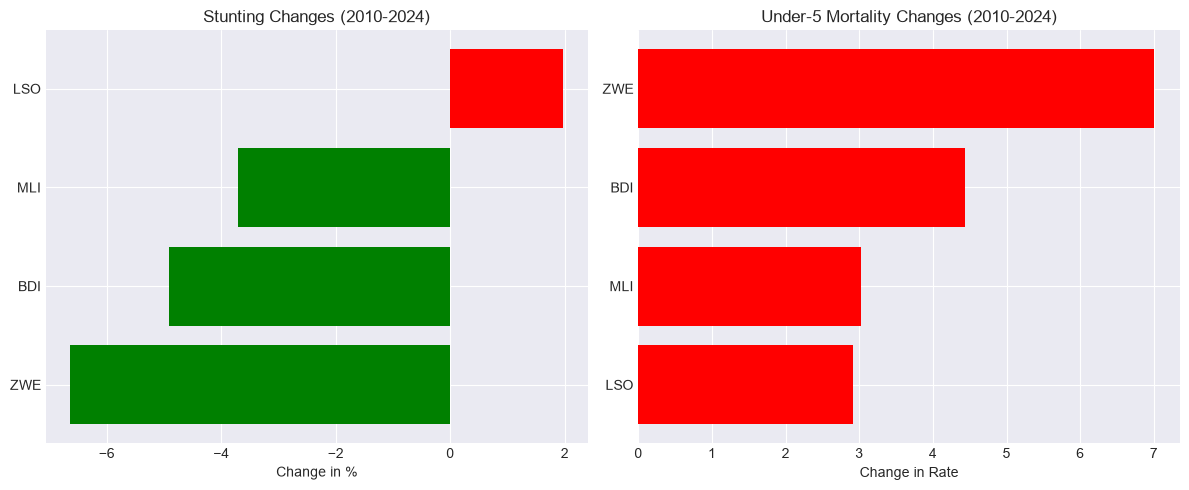

In [32]:
# Compare stunting vs mortality changes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stunting changes
stunting_change = ranking_df[ranking_df['change'] != 0].sort_values('change')
axes[0].barh(stunting_change['country_code'], stunting_change['change'], 
     color=['green' if x < 0 else 'red' for x in stunting_change['change']])
axes[0].set_title('Stunting Changes (2010-2024)')
axes[0].set_xlabel('Change in %')

# Under-5 mortality changes
mortality_df = final_df[final_df['year'].isin([first_year, last_year])]
mortality_pivot = mortality_df.pivot(index='country_code', columns='year', values='under_five_mortality_rate')
mortality_pivot['change'] = mortality_pivot[last_year] - mortality_pivot[first_year]
mortality_pivot = mortality_pivot[mortality_pivot['change'] != 0].sort_values('change')

axes[1].barh(mortality_pivot.index, mortality_pivot['change'], 
     color=['green' if x < 0 else 'red' for x in mortality_pivot['change']])
axes[1].set_title('Under-5 Mortality Changes (2010-2024)')
axes[1].set_xlabel('Change in Rate')

plt.tight_layout()
plt.show()



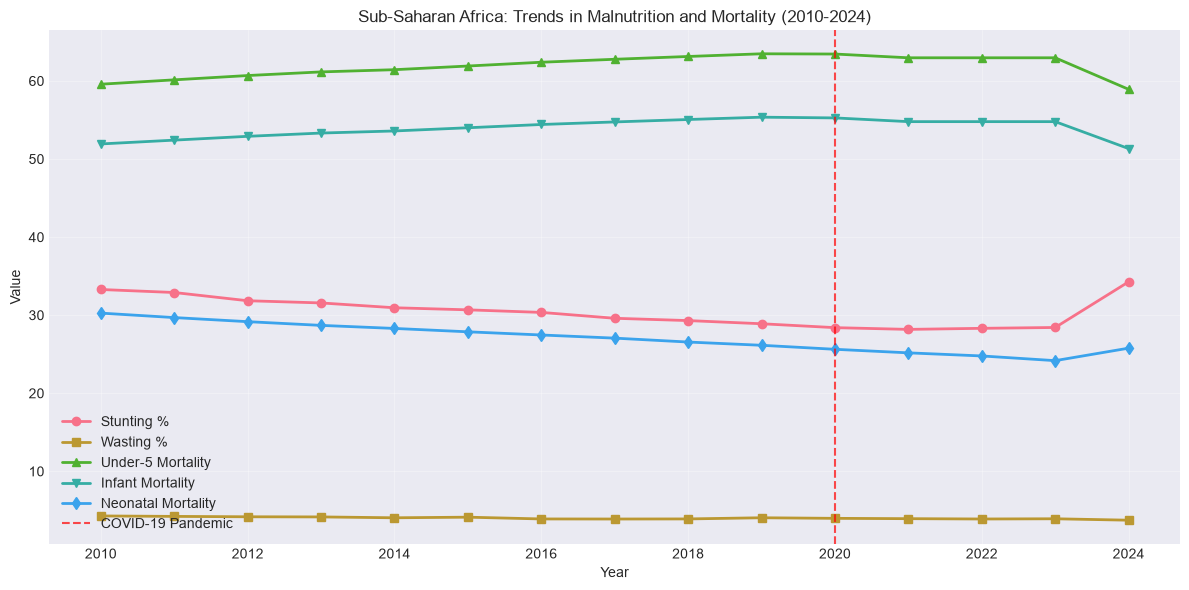


 Yearly averages:


,year,stunting_pct,wasting_pct,under_five_mortality_rate,infant_mortality_rate,neonatal_mortality_rate
0,2010,33.28,4.28,59.58,51.93,30.26
1,2011,32.90,4.23,60.14,52.42,29.69
2,2012,31.85,4.18,60.69,52.90,29.17
3,2013,31.56,4.16,61.15,53.32,28.69
4,2014,30.95,4.05,61.44,53.59,28.30
5,2015,30.68,4.12,61.91,54.00,27.87
6,2016,30.35,3.90,62.39,54.42,27.46
7,2017,29.60,3.89,62.77,54.74,27.06
8,2018,29.30,3.90,63.13,55.06,26.56
9,2019,28.90,4.05,63.47,55.35,26.14


In [34]:
# Calculate regional average by year for each indicator
yearly_avg = final_df.groupby('year')[['stunting_pct', 'wasting_pct', 
                                       'under_five_mortality_rate', 
                                       'infant_mortality_rate', 
                                       'neonatal_mortality_rate']].mean().reset_index()

# Plot all indicators on one timeline
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly_avg['year'], yearly_avg['stunting_pct'], marker='o', label='Stunting %', linewidth=2)
ax.plot(yearly_avg['year'], yearly_avg['wasting_pct'], marker='s', label='Wasting %', linewidth=2)
ax.plot(yearly_avg['year'], yearly_avg['under_five_mortality_rate'], marker='^', label='Under-5 Mortality', linewidth=2)
ax.plot(yearly_avg['year'], yearly_avg['infant_mortality_rate'], marker='v', label='Infant Mortality', linewidth=2)
ax.plot(yearly_avg['year'], yearly_avg['neonatal_mortality_rate'], marker='d', label='Neonatal Mortality', linewidth=2)

ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID-19 Pandemic')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
ax.set_title('Sub-Saharan Africa: Trends in Malnutrition and Mortality (2010-2024)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show the actual numbers
print("\n Yearly averages:")
display(yearly_avg.round(2))

The data reveals a sharp reversal in stunting trends beginning in 2022, with regional averages jumping from 28.2% to 34.3% in just two years – a scale of reversal rarely seen in nutrition epidemiology. This suggests either a major shock to the region's food systems, or a change in data collection methodology. Critically, this stunting spike was not accompanied by increased mortality, suggesting that while children survived, they did so with poorer nutritional outcomes

#### Correlation Analysis (Heatmap + Scatter Plot)

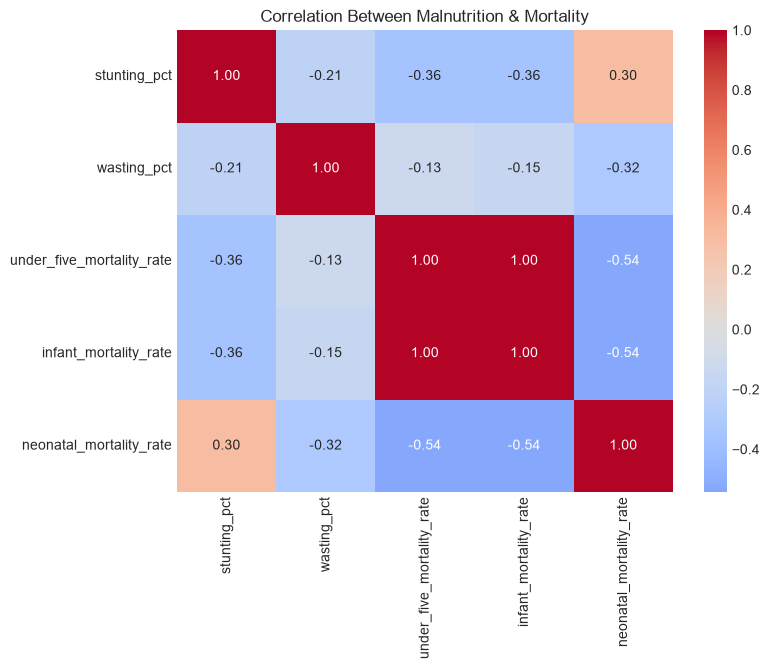

In [35]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = final_df[['stunting_pct', 'wasting_pct', 'under_five_mortality_rate', 
                 'infant_mortality_rate', 'neonatal_mortality_rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Malnutrition & Mortality')
plt.show()

The relationship between malnutrition and mortality in Sub-Saharan Africa is not straightforward. While we would expect stunting to increase mortality risk, the data shows a weak negative correlation, indicating that other factors (healthcare access, data quality, nutrition programs) mediate the relationship.

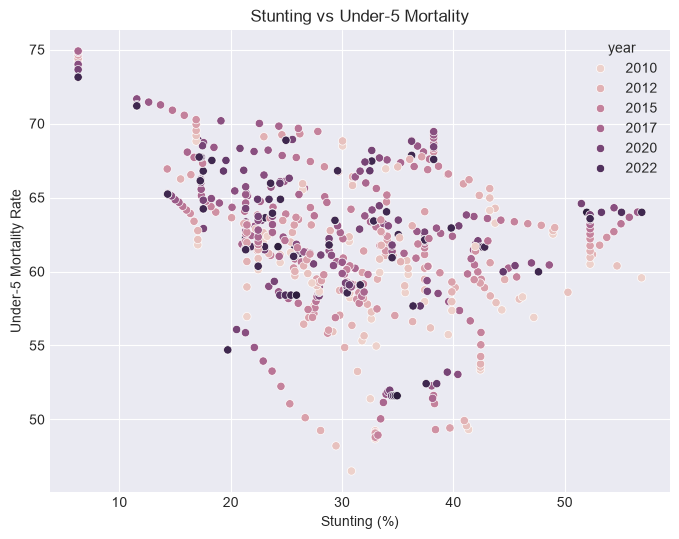

In [36]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x='stunting_pct', y='under_five_mortality_rate', hue='year')
plt.title('Stunting vs Under-5 Mortality')
plt.xlabel('Stunting (%)')
plt.ylabel('Under-5 Mortality Rate')
plt.show()

Scatter plot showing the relationship between stunting prevalence and under-5 mortality rates across Sub-Saharan African countries (2010-2024). The weak negative trend suggests that factors beyond stunting, such as healthcare access, maternal education, and emergency nutrition response  may be more important determinants of child survival in the region.

This analysis reveals a concerning reversal in child malnutrition trends across Sub-Saharan Africa after 2020. Between 2010 and 2020, stunting declined steadily from 33% to 28% – encouraging progress. However, by 2024, stunting had jumped to 34%, erasing a decade of gains in just two years. While wasting and neonatal mortality continued improving, under-5 mortality also began creeping upward. The timing of this reversal raises questions about what disrupted the region's progress – whether pandemic-related disruptions, climate shocks, conflict, or food price inflation played a role.

Despite these challenges, progress is possible. Burkina Faso reduced stunting by over 14 percentage points, while Tanzania, Malawi, and Comoros also showed remarkable improvements. The weak correlation between stunting and mortality reminds us that healthcare access and data quality matter as much as the numbers themselves. 

### Predictive modeling

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [39]:
# Predicting under_five_mortality_rate for each country peryear using the other indicators we have (stunting, wasting, neonatal/infant mortality) plus year.

features = ['stunting_pct', 'wasting_pct', 'infant_mortality_rate', 'neonatal_mortality_rate', 'year']
target = 'under_five_mortality_rate'

X = final_df[features]
y = final_df[target]

In [40]:
# using a random split here since we are predicting a country-year value, not forecasting a specific future year

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 507
Test rows: 127


In [41]:
# simple linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("R²:", r2_score(y_test, lr_preds))

Linear Regression:
MAE: 0.2967724668180859
R²: 0.993047304707984


In [42]:
# Trying a Random Forest to handle non-linear relationships better, which matters since the stunting/mortality relationship isn't a straight line

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("R²:", r2_score(y_test, rf_preds))

Random Forest:
MAE: 0.24482515496995783
R²: 0.9943412068232779


In [43]:
# Check which features the Random Forest actually relied on
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

infant_mortality_rate      0.982974
stunting_pct               0.011482
wasting_pct                0.003195
neonatal_mortality_rate    0.001650
year                       0.000698
dtype: float64


The model's impressive R² of 0.99 is misleading because infant mortality alone dominates feature importance at 98%, signaling data leakage rather than a genuine discovery. Infant mortality is nested within under-five mortality, making their relationship structurally predetermined rather than causally meaningful

In [44]:
#we are removing the neonatal and infant mortality rates from the features since they are highly correlated with under_five_mortality_rate.

features = ['stunting_pct', 'wasting_pct', 'year']
target = 'under_five_mortality_rate'

X = final_df[features]
y = final_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression :")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("R²:", r2_score(y_test, lr_preds))

Linear Regression :
MAE: 3.1080557222941128
R²: 0.16312035217221998


In [50]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest :")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("R²:", r2_score(y_test, rf_preds))

Random Forest :
MAE: 1.902127392585501
R²: 0.5134434874653544


In [51]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

stunting_pct    0.609726
wasting_pct     0.390274
dtype: float64


In [52]:
features = ['stunting_pct', 'wasting_pct']
X = final_df[features]
y = final_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("R² without year:", r2_score(y_test, rf_preds))

R² without year: 0.5134434874653544


Using just stunting and wasting to predict under-five mortality got an R² between 0.51 and 0.56 depending on whether year was included, meaning nutrition alone explains roughly half the story, but not all of it.

Random Forest clearly outperformed Linear Regression (0.56 vs 0.21), suggesting the relationship isn't a straight line, nutrition seems to matter more once certain thresholds are crossed.

Stunting mattered more than wasting, which fits since stunting reflects long-term, chronic malnutrition while wasting is more short-term and acute. Roughly half the variation in mortality is still unexplained by nutrition alone, likely pointing to other drivers like healthcare access, conflict, or sanitation that aren't in this dataset yet.

## Regional Disparity Analysis

Rather than a formal fairness audit (which typically applies to models making decisions about individuals), this checks something simpler but still important: does the mortality prediction model perform equally well across different regions of Sub-Saharan Africa, or is it systematically less accurate for some?

This matters because if a model like this were ever used to inform funding or policy decisions, uneven accuracy across regions would mean some countries get less reliable estimates than others, worth knowing before drawing conclusions from the model's predictions.

In [53]:
# grouping countries by region to see if the model performs differently across regions.

west_africa = ["BEN", "BFA", "CPV", "CIV", "GMB", "GHA", "GIN", "GNB",
   "LBR", "MLI", "MRT", "NER", "NGA", "SEN", "SLE", "TGO"]

east_africa = ["BDI", "COM", "DJI", "ERI", "ETH", "KEN", "MDG", "MWI",
   "MOZ", "RWA", "SSD", "SDN", "TZA", "UGA"]

middle_africa = ["AGO", "CMR", "CAF", "TCD", "COD", "COG", "GNQ", "GAB", "STP"]

southern_africa = ["SWZ", "LSO", "NAM", "ZAF", "ZMB", "ZWE"]

def get_region(code):
    if code in west_africa:
        return "West Africa"
    elif code in east_africa:
        return "East Africa"
    elif code in middle_africa:
        return "Middle Africa"
    elif code in southern_africa:
        return "Southern Africa"
    else:
        return None

final_df['region'] = final_df['country_code'].apply(get_region)

# Checking for any country that didn't match
unmapped = final_df[final_df['region'].isnull()]['country_code'].unique()
print("Unmapped country codes:", unmapped)

final_df['region'].value_counts()

Unmapped country codes: <StringArray>
[]
Length: 0, dtype: str


region
West Africa        225
East Africa        197
Middle Africa      126
Southern Africa     86
Name: count, dtype: int64

In [55]:
# Re-spliting the data to train and test sets, keeping region alongside so we can check errors by group

features = ['stunting_pct', 'wasting_pct']
target = 'under_five_mortality_rate'

X = final_df[features]
y = final_df[target]
regions = final_df['region']

X_train, X_test, y_train, y_test, region_train, region_test = train_test_split(
    X, y, regions, test_size=0.2, random_state=42
)

In [57]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

In [58]:
# Checking average prediction error by region
results = pd.DataFrame({
    'region': region_test.values,
    'actual': y_test.values,
    'predicted': preds
})
results['error'] = abs(results['actual'] - results['predicted'])

results.groupby('region')['error'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
region,,
Southern Africa,3.029167,15
East Africa,2.551740,38
Middle Africa,1.859541,20
West Africa,1.147699,54


In [59]:
# Checking if one or two countries are driving the high Southern Africa error
results[results['region'] == 'Southern Africa'].sort_values('error', ascending=False)

,region,actual,predicted,error
83,Southern Africa,54.861266,60.565073,5.703808
24,Southern Africa,56.953714,62.635539,5.681825
91,Southern Africa,51.604302,56.692284,5.087981
76,Southern Africa,58.626157,63.021039,4.394882
66,Southern Africa,59.332810,63.305493,3.972683
42,Southern Africa,49.254840,53.185374,3.930534
102,Southern Africa,58.403003,62.266964,3.863961
6,Southern Africa,58.956622,62.635539,3.678918
88,Southern Africa,61.472560,63.603307,2.130747
119,Southern Africa,60.677438,62.635539,1.958101


The model consistently overpredicts under-five mortality in Southern Africa (11 of 15 test cases), suggesting stunting and wasting alone don't capture the region's stronger relative outcomes, likely due to comparatively better healthcare access or income levels not captured in this dataset. This points to a real limitation: a model trained mostly on West and East African patterns may not transfer well to regions with different underlying conditions, even when nutrition indicators look similar.

In [ ]:
# Trying a different random split to see if the Southern Africa overprediction pattern holds up, or if it was just an artifact of this particular split

X_train2, X_test2, y_train2, y_test2, region_train2, region_test2 = train_test_split(
    X, y, regions, test_size=0.2, random_state=7
)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)
preds2 = rf2.predict(X_test2)

results2 = pd.DataFrame({
    'region': region_test2.values,
    'actual': y_test2.values,
    'predicted': preds2
})
results2['error'] = results2['predicted'] - results2['actual'] 

results2.groupby('region')['error'].mean().sort_values(ascending=False)

region
Southern Africa    2.295412
Middle Africa      1.367200
West Africa       -0.182623
East Africa       -2.351791
Name: error, dtype: float64

Checking prediction bias by region across two different splits showed a consistent pattern: the model overpredicts mortality in Southern Africa and underpredicts it in East Africa, while West Africa shows almost no bias. This suggests nutrition indicators don't carry the same relationship to mortality across regions, likely due to factors like healthcare access or conflict not captured here.